# Assignment 2
Tan Ze Qi Christian Lambayong A0252452L

Github: https://github.com/chrstntan/DSA4262/tree/main/Assignment%202

## Introduction
Online platforms contain large volumes of user-generated text where individuals may express psychological distress. Automatically detecting stress-related language can help identify trends in mental well-being and inform support initiatives.

This project builds a binary classification model to distinguish between “Stressed” and “Non-stressed” Reddit posts using the Dreadit dataset. The aim is to understand how stress is expressed linguistically and evaluate whether such models can be responsibly used in real-world settings.

\* *`"dreaddit-train.csv"` and `"dreaddit-test.csv"` should be in the same folder*.

## Libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from transformers import BertTokenizer
import torch
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score

# Data Processing

In [24]:
df = pd.read_csv("dreaddit-train.csv")

In [25]:
df.head()

,subreddit,post_id,sentence_range,text,id,label,confidence,social_timestamp,social_karma,syntax_ari,...,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,social_upvote_ratio,social_num_comments,syntax_fk_grade,sentiment
0,ptsd,8601tu,"(15, 20)","He said he had not felt that way before, sugge...",33181,1,0.8,1521614353,5,1.806818,...,1.000,1.1250,1.0,1.77000,1.52211,1.89556,0.86,1,3.253573,-0.002742
1,assistance,8lbrx9,"(0, 5)","Hey there r/assistance, Not sure if this is th...",2606,0,1.0,1527009817,4,9.429737,...,1.125,1.0000,1.0,1.69586,1.62045,1.88919,0.65,2,8.828316,0.292857
2,ptsd,9ch1zh,"(15, 20)",My mom then hit me with the newspaper and it s...,38816,1,0.8,1535935605,2,7.769821,...,1.000,1.1429,1.0,1.83088,1.58108,1.85828,0.67,0,7.841667,0.011894
3,relationships,7rorpp,"[5, 10]","until i met my new boyfriend, he is amazing, h...",239,1,0.6,1516429555,0,2.667798,...,1.000,1.1250,1.0,1.75356,1.52114,1.98848,0.50,5,4.104027,0.141671
4,survivorsofabuse,9p2gbc,"[0, 5]",October is Domestic Violence Awareness Month a...,1421,1,0.8,1539809005,24,7.554238,...,1.000,1.1250,1.0,1.77644,1.64872,1.81456,1.00,1,7.910952,-0.204167


In [26]:
df_test = pd.read_csv("dreaddit-test.csv")

# Model 1: TF-IDF + SVM
## Train

In [27]:
lex_cols = [c for c in df.columns if c.startswith("lex_")]

df_model = df[["text", "label", "subreddit"] + lex_cols]

print(df_model.shape)


(2838, 105)


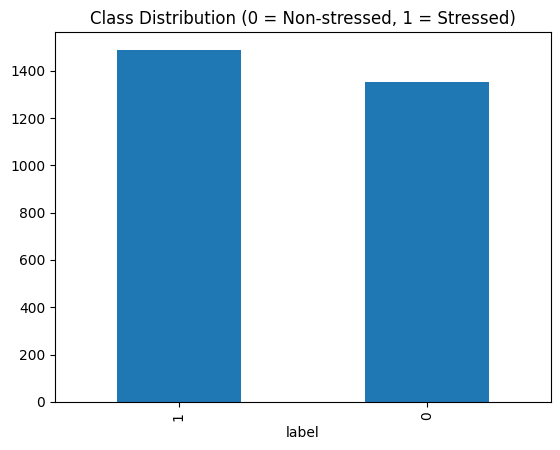

In [28]:
df_model['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Non-stressed, 1 = Stressed)")
plt.show()


From the graph, there seems to be no strong class imbalance.

In [29]:
X = df_model.drop(columns=["label"])
y = df_model["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [30]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words=None
)

X_train_text = tfidf.fit_transform(X_train["text"])
X_val_text = tfidf.transform(X_val["text"])

In [31]:
scaler = StandardScaler()

X_train_lex = scaler.fit_transform(X_train[lex_cols])
X_val_lex = scaler.transform(X_val[lex_cols])

In [32]:
X_train_final = hstack([X_train_text, X_train_lex])
X_val_final = hstack([X_val_text, X_val_lex])

In [33]:
model = LinearSVC()

model.fit(X_train_final, y_train)

c:\Users\chrst\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [34]:
preds = model.predict(X_val_final)

print(classification_report(y_val, preds))
print("F1-score:", f1_score(y_val, preds))

              precision    recall  f1-score   support

           0       0.75      0.76      0.75       270
           1       0.78      0.77      0.77       298

    accuracy                           0.76       568
   macro avg       0.76      0.76      0.76       568
weighted avg       0.76      0.76      0.76       568

F1-score: 0.7728813559322034


## Test

In [35]:
lex_cols = [c for c in df.columns if c.startswith("lex_")]

df_test = df_test[["text", "label", "subreddit"] + lex_cols]

In [36]:
X_test_text = tfidf.transform(df_test["text"])

X_test_lex = scaler.transform(df_test[lex_cols])

X_test_final = hstack([X_test_text, X_test_lex])

In [37]:
svm_preds = model.predict(X_test_final)

In [38]:
print("TF-IDF + SVM Test F1:", f1_score(df_test["label"], svm_preds))

print(classification_report(df_test["label"], svm_preds))

TF-IDF + SVM Test F1: 0.753004005340454
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       346
           1       0.74      0.76      0.75       369

    accuracy                           0.74       715
   macro avg       0.74      0.74      0.74       715
weighted avg       0.74      0.74      0.74       715



# Model 2: BERT
## Train

In [39]:
df_bert = df[["text", "label", "subreddit"]]

train_df, val_df = train_test_split(
    df_bert, test_size=0.2, stratify=df_bert["label"], random_state=42
)

In [40]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [41]:
train_encodings = tokenizer(
    train_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_df["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)


In [42]:
class DreaditDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = DreaditDataset(train_encodings, train_df["label"])
val_dataset = DreaditDataset(val_encodings, val_df["label"])


In [43]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [44]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {"f1": f1_score(labels, preds)}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=1e-5,
    weight_decay=0.05,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()


Epoch,Training Loss,Validation Loss,F1
1,0.455677,0.412857,0.819728
2,0.325832,0.410989,0.843493


TrainOutput(global_step=568, training_loss=0.419854053309266, metrics={'train_runtime': 366.9355, 'train_samples_per_second': 12.373, 'train_steps_per_second': 1.548, 'total_flos': 597262095667200.0, 'train_loss': 0.419854053309266, 'epoch': 2.0})

In [45]:
trainer.evaluate()


{'eval_loss': 0.41098925471305847,
 'eval_f1': 0.8434925864909391,
 'eval_runtime': 12.9666,
 'eval_samples_per_second': 43.805,
 'eval_steps_per_second': 5.476,
 'epoch': 2.0}

## Test

In [46]:
test_encodings = tokenizer(
    df_test["text"].tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [47]:
test_dataset = DreaditDataset(test_encodings, df_test["label"])

In [48]:
bert_output = trainer.predict(test_dataset)

bert_logits = bert_output.predictions
bert_labels = bert_output.label_ids
bert_preds = np.argmax(bert_logits, axis=1)

In [49]:
print("BERT Test F1:", f1_score(df_test["label"], bert_preds))

print(classification_report(df_test["label"], bert_preds))

BERT Test F1: 0.8097686375321337
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       346
           1       0.77      0.85      0.81       369

    accuracy                           0.79       715
   macro avg       0.80      0.79      0.79       715
weighted avg       0.80      0.79      0.79       715



# Analyses

## 1. Model Comparison TF-IDF+SVM vs BERT

**Question:** Which Model is better at classifying stress text?

**Method**: Use the Higher F1 score 


In [50]:
print("TF-IDF + SVM Test Accuracy:", accuracy_score(df_test["label"], svm_preds))
print("TF-IDF + SVM Test F1:", f1_score(df_test["label"], svm_preds))
print("BERT Test Accuracy:", accuracy_score(df_test["label"], bert_preds))
print("BERT Test F1:", f1_score(df_test["label"], bert_preds))

TF-IDF + SVM Test Accuracy: 0.7412587412587412
TF-IDF + SVM Test F1: 0.753004005340454
BERT Test Accuracy: 0.793006993006993
BERT Test F1: 0.8097686375321337


Both TF-IDF + SVM and BERT models were evaluated on the same test datatset. While the traditional model provided a useful interpretability baseline, the fine-tuned BERT model achieved a higher F1-score and demonstrated stronger ability to capture contextual expressions of stress.

The difference in F1 score is likely due to TF-IDF + SVM reliance on engineered features and word importance while BERT learns contextual meaning directly from raw text. Even with lexical features, the TF-IDF model treats text primarily as weighted tokens, whereas BERT models relationships between words.

Although the TF-IDF + SVM model is a strong traditional approach, stress expression is often:

* Context-dependent
* Narrative-driven
* Not always keyword-heavy

BERT’s contextual embeddings allow it to better capture nuanced and implicit stress expressions. The higher F1 score supports selecting BERT for deeper analysis. The results from BERT will mainly be used for the remaining analyses.

---


## 2. Subreddit-Level Classification

**Question:** Are some communities easier to classify than others?

**Method:** F1-score was computed separately for each subreddit.

In [51]:
bert_results = df_test.copy()
bert_results["pred"] = bert_preds

In [52]:
subreddit_metrics = []

for sub in bert_results["subreddit"].unique():
    sub_df = bert_results[bert_results["subreddit"] == sub]

    subreddit_metrics.append({
        "subreddit": sub,
        "F1": f1_score(sub_df["label"], sub_df["pred"]),
        "Precision": precision_score(sub_df["label"], sub_df["pred"]),
        "Recall": recall_score(sub_df["label"], sub_df["pred"]),
        "Num_Posts": len(sub_df)
    })

metrics_df = pd.DataFrame(subreddit_metrics).sort_values("F1", ascending=False)
metrics_df

,subreddit,F1,Precision,Recall,Num_Posts
8,stress,0.900000,0.900000,0.900000,14
6,domesticviolence,0.893617,0.893617,0.893617,72
3,assistance,0.871795,0.944444,0.809524,66
9,food_pantry,0.857143,0.750000,1.000000,6
1,anxiety,0.849162,0.808511,0.894118,147
2,ptsd,0.847059,0.818182,0.878049,127
5,almosthomeless,0.782609,0.818182,0.750000,19
7,survivorsofabuse,0.714286,0.641026,0.806452,70
0,relationships,0.706767,0.643836,0.783333,142
4,homeless,0.697674,0.600000,0.833333,52


Performance varies significantly across communities. Subreddits like stress and domesticviolence show a high F1 score (0.9~0.88) while subreddits like relationships and homeless have low F1 score (0.69~0.71). 

Different subreddits likely have different linguistic norms. Some communities may encourage direct emotional disclosure while others favour storytelling or practical discussion and some may express distress implicitly rather than explicitly.

Model likely performs better when emotional markers are explicit and less effectively when stress is implied within longer narratives.

**Implications for Deployment** : Models should be validated per domain. Performance cannot be assumed uniform across communities.

---

## 3.Cross-Subreddit Generalisation Sensitivity

**Question:** Does the model generalise equally well across subreddits?

**Method:** F1-scores were analysed per subreddit and compared against the number of posts. This allowed examination of whether performance differences were associated with dataset size.

In [53]:
metrics_df

,subreddit,F1,Precision,Recall,Num_Posts
8,stress,0.900000,0.900000,0.900000,14
6,domesticviolence,0.893617,0.893617,0.893617,72
3,assistance,0.871795,0.944444,0.809524,66
9,food_pantry,0.857143,0.750000,1.000000,6
1,anxiety,0.849162,0.808511,0.894118,147
2,ptsd,0.847059,0.818182,0.878049,127
5,almosthomeless,0.782609,0.818182,0.750000,19
7,survivorsofabuse,0.714286,0.641026,0.806452,70
0,relationships,0.706767,0.643836,0.783333,142
4,homeless,0.697674,0.600000,0.833333,52


***Example 1***

food_pantry (N = 6): F1 = 0.857, Precision = 0.75, Recall = 1.00

***Example 2***

anxiety (N = 147): F1 = 0.847, Precision = 0.809, Recall = 0.894

Although food_pantry has a high F1-score, it is based on only six posts. In such a small sample, one misclassification can significantly shift precision or recall. In contrast, larger subreddits such as anxiety and ptsd (N = 127) one misclassifcation will not skew the data significantly.

Larger datasets improve performance reliability:

1. **Reduced Metric Sensitivity:** In small datasets, a single misclassification can alter precision or recall sharply. With larger datasets, individual prediction errors have less impact on overall metrics.

2. **Greater Linguistic Diversity:** Larger communities contain more varied expressions of stress and non-stress. This forces the model to learn generalisable patterns rather than specififc wordings in the subreddit.

3. **More Representative Evaluation:** Large test samples better approximate real-world data variation. Performance measured on larger groups is therefore a more realistic indicator of deployment reliability.

4. **Lower Risk of Inflated Scores:** Small datasets may produce artificially high scores simply due to limited variability. Larger datasets reduce the likelihood that high performance is due to chance.

**Implications for Deployment:** Performance metrics should be interpreted alongside sample size. High F1-scores in very small subreddits should be treated with caution, as they may not generalise beyond the limited examples observed. In contrast, larger subreddits provide a more reliable and realistic estimate of real-world model behaviour because the evaluation reflects a broader range of linguistic variation. Therefore, deployment decisions should prioritise performance stability across higher-volume communities, where metrics are less sensitive to individual posts. Another option is to augment data in the lower volume subreddits to increase the data size.

## 4. Misclassification Analysis

**Question:** Does the model misclassify posts and why?

**Method:**
Posts with high prediction confidence but incorrect labels were manually reviewed.

In [54]:
df_test["pred"] = bert_preds

false_positives = df_test[(df_test["pred"] == 1) & (df_test["label"] == 0)]

false_negatives = df_test[(df_test["pred"] == 0) & (df_test["label"] == 1)]

In [55]:
false_positives.head()

,text,label,subreddit,lex_liwc_WC,lex_liwc_Analytic,lex_liwc_Clout,lex_liwc_Authentic,lex_liwc_Tone,lex_liwc_WPS,lex_liwc_Sixltr,...,lex_dal_max_pleasantness,lex_dal_max_activation,lex_dal_max_imagery,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,pred
4,I haven’t said anything to him yet because I’m...,0,relationships,78,4.96,50.00,71.23,89.84,15.60,21.79,...,3.0000,2.5000,3.0,1.125,1.1429,1.0,1.75642,1.43582,1.91725,1
18,"If I go to an interview for example, I'll know...",0,anxiety,114,12.16,8.02,84.91,41.64,22.80,18.42,...,2.7500,2.8000,3.0,1.000,1.0000,1.0,1.70351,1.40571,1.87888,1
40,"So, I've been homeless since about the first, ...",0,homeless,83,4.29,2.03,98.25,25.77,13.83,12.05,...,2.8333,2.6250,3.0,1.200,1.1429,1.0,1.67694,1.50541,1.94570,1
47,I'll try to keep this short. I've never been a...,0,relationships,86,6.37,2.45,97.26,69.60,21.50,10.47,...,2.8462,2.6250,3.0,1.125,1.2222,1.0,1.71069,1.42278,1.89592,1
50,None of the issues we discuss get addressed. 6...,0,relationships,74,75.57,13.98,92.70,1.00,14.80,12.16,...,2.7143,2.6364,3.0,1.000,1.1250,1.0,1.73322,1.55294,1.86978,1


In [56]:
false_negatives.head()

,text,label,subreddit,lex_liwc_WC,lex_liwc_Analytic,lex_liwc_Clout,lex_liwc_Authentic,lex_liwc_Tone,lex_liwc_WPS,lex_liwc_Sixltr,...,lex_dal_max_pleasantness,lex_dal_max_activation,lex_dal_max_imagery,lex_dal_min_pleasantness,lex_dal_min_activation,lex_dal_min_imagery,lex_dal_avg_activation,lex_dal_avg_imagery,lex_dal_avg_pleasantness,pred
53,"Hello all, for the next two years I’ll probabl...",1,homeless,59,40.89,4.53,84.61,85.20,11.80,11.86,...,3.0000,2.6667,3.0,1.3333,1.0000,1.0,1.75929,1.47925,1.99221,0
62,&#x200B; I'm sorry if this isn't appropriate f...,1,anxiety,31,1.00,1.00,99.00,1.00,7.75,9.68,...,2.3750,2.8182,2.6,1.2000,1.1818,1.0,1.63145,1.28148,1.91734,0
66,Last week while my girlfriend was out of the c...,1,assistance,92,43.39,98.04,33.70,11.64,18.40,17.39,...,2.6250,2.8889,3.0,1.0000,1.1250,1.0,1.77259,1.60741,1.82796,0
105,Do you huddle up in the corner of some obscure...,1,homeless,77,52.91,34.83,93.03,74.18,12.83,15.58,...,2.8333,2.6667,3.0,1.0000,1.3333,1.0,1.74337,1.51884,1.90137,0
107,I don't necessarily want to come out and tell ...,1,survivorsofabuse,61,19.01,68.85,22.13,1.13,10.17,14.75,...,2.7000,2.6250,3.0,1.3333,1.1818,1.0,1.70270,1.62692,1.90014,0


### False Positive

\* *These examples where from my runs. It may differ with each run.*

***Example 1***

I'll try to keep this short. I've never been able to feel empathy towards other people, I'm not a sociopath or anything (as far as I know), I know when I should feel bad for/with somebody but I can't make myself care as much as I want to. _ Anyways, my mothers best friend of 45 years just killed himself and she's pretty torn up about it. I gave her a hug and what not but I have no idea what else I'm supposed to do.

***Example 2***

So, I've been homeless since about the first, but I was expecting this. What I wasn't expecting was the changes I've made in my life since becoming homeless. Thankfully I have a job, so I do have money. But I hate everywhere that's affordable to eat! I've been a big junk food/fast food fan for years, so I'm a bit overweight, but lately, I just don't seem to care for meat as much, and fast food is just so.. gross right now.

***Insight***

In Example 1, phrases such as "I have no idea what else I'm supposed to do" and "I can't make myself care as much as I want to" may have triggered the model’s stress indicators. However, these phrases were not interpreted within their broader context. A similar pattern can be observed in Example 2, where the user states "But I hate everywhere". Although this phrase appears emotionally intense and could act as a trigger for stress detection, the overall context of the post is not stress-related.

From these two false positive examples, it is evident that emotionally heavy phrases can activate stress indicators within the model, even when the posts themselves are not genuinely expressing stress. This suggests that the model might not be able to fully incoporate contextual meaning to all post.

### False Negative

***Example 1***

Hello all, for the next two years Iâ€™ll probably be living in my truck. I am going to college for free (thanks AmeriCorps) but I canâ€™t afford to live in a real home. So I live in my truck. Any tips for keeping it clean and keeping things orderly? Itâ€™s so much harder than I thought it would be.

***Example 2***

I'm sorry if this isn't appropriate for the thread. I don't really know if it's appropriate anywhere. I guess that's the point? "Am I normal or am I fucked up?"

***Insight***

For Example 1, the user describes their experience with becoming homeless, but the language used does not contain strongly explicit emotional vocabulary. The stress indicators are more subtle and embedded within the narrative. As a result, the model may have failed to recognise the seriousness of the content because it did not contain the intense emotional markers typically associated with stress.

A similar pattern can be observed in Example 2. Although the user questions their own mental state, the phrasing is indirect and framed as uncertainty rather than explicit distress. The stress signal is implied rather than clearly articulated, which may have contributed to the misclassification.



Strong emotional language can increase stress probability. However there are some exceptions:

* Advice posts may quote distress without expressing it.
* Narrative posts may describe hardship without emotional intensity markers.
* Sarcasm can also mask distress be unintentional markers.
* Users discussing stress academically rather than personally.

The model may not fully understand emotional intent. As such, human interpretation remains necessary in sensitive applications.

**Implications for Deployment:** The model can over-flag emotionally expressive but non-distressed users and also miss users who suppress or indirectly communicate stress. While increasing the number of data may improve the reliability, it may be recommended to have human reviews. Missing users who suppress or indirectly communicate stress could be dangerous, as such having another layer of check could be benefitial.

---

## 5. Stress-Predictive Linguistic Features

**Question:** Which linguistic patterns most strongly signal stress compared to non-stress posts?

**Method:** To isolate meaningful patterns, only high-confidence correct predictions were analysed. This ensures that the analysis reflects posts the model is very certain about, reducing noise from borderline or misclassified examples.

In [57]:
probs = torch.nn.functional.softmax(torch.tensor(bert_logits), dim=1).numpy()

confidence = probs.max(axis=1)

In [58]:
df_test["pred"] = bert_preds
df_test["confidence"] = confidence

In [59]:
high_conf_stress = df_test[
    (df_test["pred"] == 1) &
    (df_test["label"] == 1) &
    (df_test["confidence"] > 0.90)
]

high_conf_nonstress = df_test[
    (df_test["pred"] == 0) &
    (df_test["label"] == 0) &
    (df_test["confidence"] > 0.90)
]

high_conf_stress[["text", "confidence"]].sort_values("confidence", ascending=False).head(10)

,text,confidence
366,I just don't know what's real anymore. I can't...,0.968845
367,Am I mentally ill? I want to kill myself but I...,0.968248
667,I have very strong urges to hurt myself. I've ...,0.967999
432,I feel so vulnerable and unsure of myself all ...,0.967830
496,I’m leaving for the airport right now and i’m ...,0.967688
135,"I'm not competent to deal with life, despite b...",0.967607
599,Lately I've just been having that terrible fee...,0.966900
579,And now that they have been living separately ...,0.966758
608,I have panic attack after panic attack and I t...,0.966620
137,Every once in a while I get the concept of dea...,0.966569


In [60]:
high_conf_nonstress[["text", "confidence"]].sort_values("confidence", ascending=False).head(10)

,text,confidence
384,So we are striving to find that balance betwee...,0.944569
157,"Title gives the gist of it, the link has a bit...",0.943865
244,If you wish to contribute to the academic res...,0.943074
145,Our study involves an online survey (approx. 4...,0.942834
697,"Save yourselves, and get a doggo if you can. *...",0.940114
457,"Entering my invite code would give me points, ...",0.939081
502,Last time we talked she promised that it would...,0.938226
587,Just goes to show: It's not the suit. It's how...,0.937669
109,"Hi guys, I'm a final year psychology student a...",0.937654
713,Here's the link to my amazon wish list where t...,0.937618


### Stressed Post

***Example 1***

I just don't know what's real anymore. I can't live with everyone in my life thinking that I'm crazy AND a hysterical slut. I just can't do this anymore. I'm so ashamed I can't be in this skin anymore. I'm starting to get scared.

***Example 2***

Am I mentally ill? I want to kill myself but I'm to scared to even do that. I'm supposed to be starting college in the fall but I don't think that'll work out well. This entire post is probably gibberish but I haven't slept in almost 2 days and I can't think straight. I don't know what to do but I can't keep doing this.

***Insights***

From the examples, stress posts show first-person emotional language. Example phrases:

* "I just can't do this anymore."
* "I'm starting to get scared."
* "I want to kill myself but I'm to scared to even do that"

These posts typically contain repeated first-person pronouns ("I"), express a loss of control, use emotionally charged language (scared, kill, can't) and describe personal suffering or distressing events.

### Non-Stressed Post

***Example 1***

So we are striving to find that balance between building an inviting and encouraging community (village) and the first rungs on the ladder to independence. I read all of your posts and take mental notes as to what you are telling each other of what you need or the advice you give a newcomer. But it would be fantastic if you dropped me a note telling me of what you think. Thanks. God Bless.

***Example 2***

Hi guys, I'm a final year psychology student at university, and my dissertation is looking at the association between porn use and romantic relationship satisfaction, as well as sexual satisfaction. The link for my study is <url> I would be grateful to anyone that completes the study. In case after signing in, it redirects you to the main page, the name of my study is "Pornography Use, Romantic Relationships, and Sexual Satisfaction in Homosexual Men". Anyone interested in taking part will need to make an account for my university's online survey host site, but none of this information will be shared with me. I will only receive an ID number in case someone wants to withdraw from the questionnaire after completing it (details of how to do so can be found on the participant information sheet, which is attached to the description and introduction of the questionnaire).

***Insights***

Non-stress posts typically show informational and structured tone. Example phrases:

* "take mental notes as to what you are telling each other of what you need or the advice you give a newcomer"
* "I would be grateful to anyone that completes the study."

These posts typically have structured explanations, uses neutral and polite tone, focuses on information sharing and contains academic language.

Stress posts are often related to high emotional intensity which can involve personal crisis, social conflict, fear, shame and overwhelming emotions. These factors help the model to detect stress. Non-stress posts usually follow formal sentence structure, contain academic or procedural vocabulary and lack emotional escalation. This reduces predicted stress probability.

**Implications for Deployment:** The model should be sensitive to emotionally intense language, particularly expressions of fear, shame, crisis, or abuse. This is beneficial in deployment contexts such as mental health monitoring, where early detection of distress is important. It should also show a lower tendency to flag structured, informational, or academic posts, reducing unnecessary false alarms. However, emotionally expressive language used in non-stress contexts (e.g., sarcasm or storytelling) may still trigger stress predictions. Therefore, human reviews should be considered during real-world applications.

---


## 6. Class-Level Error Distribution

**Question:** Is performance balanced between stress and non-stress classes?

**Method:** Confusion matrix and class-specific precision/recall will be examined.


In [61]:
cm = confusion_matrix(bert_labels, bert_preds)
cm

array([[252,  94],
       [ 54, 315]])

In [62]:
report = classification_report(bert_labels, bert_preds, target_names=["Non-Stress", "Stress"])
print(report)

              precision    recall  f1-score   support

  Non-Stress       0.82      0.73      0.77       346
      Stress       0.77      0.85      0.81       369

    accuracy                           0.79       715
   macro avg       0.80      0.79      0.79       715
weighted avg       0.80      0.79      0.79       715



For the stress class, recall is higher than precision. This indicates that the model successfully identifies most true stress posts but also produces a higher number of false positives. On the other hand, for the Non-Stress class, precision is higher than recall, suggesting that when the model predicts non-stress it is usually correct, but it fails to identify some true non-stress posts. The model is overall slightly more sensitive to stress.

The language overlap between emotional non-stress posts and genuine stress posts likely contributes to false positives.

**Implications for Deployment:** If the system is intended for early intervention, prioritising higher stress recall is desirable because missing true stress cases may have serious consequences. However, excessive false positives could reduce reliability in the system and increase unnecessary review workload. As such, tuning may be required to better balance precision and recall.

In [63]:
print("BERT Test Accuracy:", accuracy_score(df_test["label"], bert_preds))
print("BERT Test F1:", f1_score(df_test["label"], bert_preds))

BERT Test Accuracy: 0.793006993006993
BERT Test F1: 0.8097686375321337


# Conclusion

The BERT stress classification model demonstrates strong contextual understanding and balanced performance, achieving an overall accuracy of 79% with a F1 score of 81%. This suggests that the model is capable of identifying stress posts with reasonable reliability.

In a real-world setting such as Singapore, the model could be deployed as a decision-support tool in online community moderation or mental health outreach platforms. For example, it could assist moderators in identifying posts that may require welfare checks, crisis support, or referral to professionals. Given the model relatively high stress recall, the model is suitable for early detection systems where missing genuine distress cases carries higher risk than missing false alarms.

However, there are some limitations that must be considered.

First, the model was trained and evaluated on Reddit data, which may not reflect Singapore’s linguistic and cultural diversity. In Singapore, many languages are used and most people are typically billingual and also mix their languages when communicating. There is also the usage of Singlish. Multilingual usage and Singlish may reduce model reliability if not explicitly represented in the training data.

Second, the model occasionally over-predicts stress due to sensitivity to emotionally intense language. While this is beneficial for early intervention, it may generate false positives in sarcastic or overly-expressive contexts. Without human oversight, this could lead to false labelling and unnecessary escalations.

Third, the variability in the subreddit-level performance suggests that results depend on language patterns specific to the domain. Communities with limited or specific linguistics norms could reduce the generalisation ability of the model.

Overall, the model shows promise as an supportive tool rather than a fully autonomous decision-maker. With appropriate tuning, local linguistic adaptation, and human oversight, it could support digital mental health initiatives. However, careful evaluation are essential before real-world deployment.